# Introduction
This web site is running a "Jupyter notebook," which allows you to execute interactive Octave
code directly in your browser. Each (part of a code) line preceeded by a percent symbol "%" is a code comment.

To execute any Octave commands, first enter the commands in a code cell, and then depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell.
I refer to this as "< shift \> < enter \>" in my instructions below.

The output from this notebook will be used to provide answers for this lesson's practice
quiz. As you proceed through the specialization, you will use more and more Jupyter notebooks
to write Octave code to implement Kalman-filter algorithms.

In [2]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

rms = @(x) sqrt(mean((x).^2)); % define root-mean-squared function

% The car has already been simulated offline and the data are stored in "observations.mat".
% We load that datafile here.
load readonly/observations.mat x z
nIter = length(x);

% Define some constants related to the problem
sigmaV  = 5*pi/180;
sigmaW  = 10*pi/180;
meanX0  = 50*pi/180;
sigmaX0 = 10*pi/180;
omega   = 2*pi/180; 
xo      = 500; 
yo      = 500; 
r       = 200; 

### Implement the particle-filter solution
The next notebook cells implement the particle-filter SIS method.

In [3]:
% Create the particles
nPart = 500;
xp = zeros(nPart,nIter);
wp = zeros(nPart,nIter);
xHatPart = zeros(nIter,1);

% Set initial random-number-generator state to make simulation 
% results repeatable. Note that Octave's random-number generator 
% is not the same as MATLAB's, so the results you compute here 
% will not be identical to those in the lesson notes.
randn("state",1); 

% Intiialize particle values and weights
xp(:,1) = meanX0 + sigmaX0*randn(nPart,1);
wp(:,1) = 1/nPart;

% Implement SIS for the rest of the trajectory
for k=2:nIter
  for cp=1:nPart
    % Draw new particle from q(x{k}|x{k-1},z{k}) = f(x{k}|x{k-1})
    xp(cp,k)   = xp(cp,k-1) + omega + sigmaW*randn(1); 
    % Compute the expected value of the measurement given x{k}
    zp         = atan((r*sin(xp(cp,k))+yo)./(r*cos(xp(cp,k))+xo));
    % Compute f(z{k}|x{k})
    likelihood = normpdf(z(k),zp,sigmaV);
    % Compute unnormalized weight 
    % wptilde(cp,k) = f(x{k}|x{k-1}) / q(x{k}|x{k-1},z{k}) *
    %                 f(z{k}|x{k}) * wp(cp,k-1) 
    wp(cp,k)   = wp(cp,k-1)*likelihood;        
  end            
  wp(:,k) = wp(:,k)/sum(wp(:,k)); % Normalize weights
  xHatPart(k) = sum(wp(:,k).*xp(:,k)); % Compute mean based on particles
  
  if mod(k,10)==0
    fprintf('Completed iteration %d out of %d\n',k,nIter);
  end
end
fprintf('Done!\n');

Completed iteration 10 out of 101
Completed iteration 20 out of 101
Completed iteration 30 out of 101
Completed iteration 40 out of 101
Completed iteration 50 out of 101
Completed iteration 60 out of 101
Completed iteration 70 out of 101
Completed iteration 80 out of 101
Completed iteration 90 out of 101
Completed iteration 100 out of 101
Done!


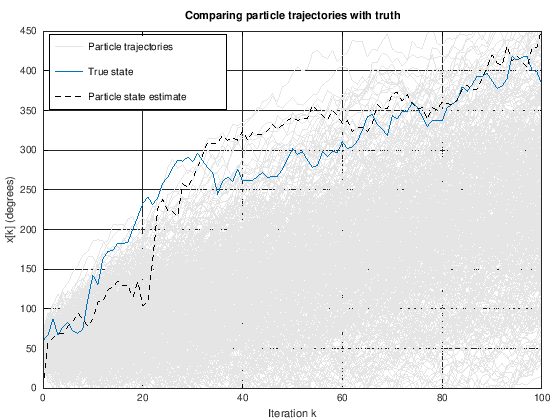

In [4]:
CL = lines;
% Plot particle trajectories as light-gray lines instead of magenta to make easier to see in Octave
h1 = plot(0:nIter-1,xp*180/pi,'color',0.9*[1 1 1]); hold on
h2 = plot(0:nIter-1,x*180/pi,'color',CL(1,:)); grid on
h3 = plot(0:nIter-1,xHatPart*180/pi,'k--');  
xlabel('Iteration k'); ylabel('x[k] (degrees)'); 
title('Comparing particle trajectories with truth');
xlim([0 nIter-1]); ylim([0 450]);
legend([h1(1),h2,h3],{'Particle trajectories','True state','Particle state estimate'},'location','northwest');

### Estimate full pdfs for visualization
Convert particles to pdf estimate using bump function

In [5]:
nR      = 500; % Evaluate pdf over this many "bins"
bumpWid = 0.1; % Bump width in bump kernel when estimating pdf
xGrid   = linspace(0,450/(180/pi),nR).'; % x locations of the bins
width   = mean(diff(xGrid)); % Average width of each bin
estPDF  = zeros(nR,nIter); % estimate of f(x{k}|Z{k})
xLowBndPart = zeros(nIter,1); % Lower confidence interval
xHiBndPart  = zeros(nIter,1); % Upper confidence interval

kernelFN = @(x) (1-x.^2).^2.*(abs(x)<=1);

for k=1:nIter % repeat for every time iteration
  [xps,iSort] = sort(xp(:,k)); % Sort particles by increasing value
  wps      = wp(iSort,k); % Weights must agree with particles
  wSum     = cumsum(wps); % Cumulative sum of sorted weights
  if wSum(1)>0.025
    xLowBndPart(k) = xps(1); 
  else 
    xLowBndPart(k)  = xps(find(wSum<0.025,1,'last'));  % Lower confidence "x"
  end
  xHiBndPart(k) = xps(find(wSum>0.975,1,'first')); % Upper confidence "x"

  for kp = 1:nPart % Add bumps together for all particles
    estPDF(:,k) = estPDF(:,k) + wps(kp)*kernelFN((xGrid-xps(kp))/bumpWid);
  end
  estPDF(:,k) = estPDF(:,k)./(sum(estPDF(:,k))*width); % Normalize
end

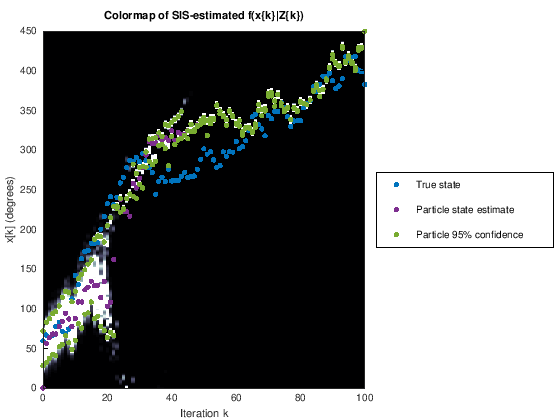

In [6]:
colormap('bone'); CL = lines;
imagesc(0:nIter-1,xGrid*180/pi,estPDF); hold on;
% If you use MATLAB, replace "caxis" with "clim".
caxis([0,prctile(estPDF(:),95)]); % more white on plot
k = (0:nIter-1).';        
hp1 = plot(k,x*180/pi,'.'); hold on
hp2 = plot(k,xHatPart*180/pi,'.','color',CL(4,:));
hp3 = plot([k;k],[xHiBndPart;xLowBndPart]*180/pi,'.','color',CL(5,:));
set([hp1,hp2,hp3],'markersize',12);
xlabel('Iteration k'); ylabel('x[k] (degrees)');
title('Colormap of SIS-estimated f(x\{k\}|Z\{k\})');
xlim([0 nIter-1]); ylim([0 450]);
legend({'True state','Particle state estimate','Particle 95% confidence'},'location','eastoutside')
set(gca,'YDir','Normal');

### Visualize particle weights
Trying to understand the problem with the basic SIS algorithm; visualize particle weights.

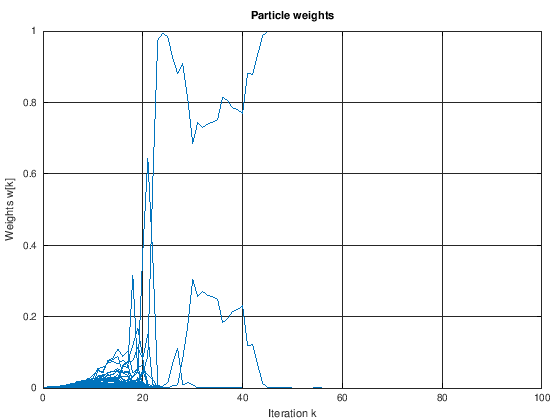

In [7]:
% Plot the particle weights versus iteration
plot(0:nIter-1,wp,'color',CL(1,:)); grid on
xlabel('Iteration k');
ylabel('Weights w[k]'); title('Particle weights');
xlim([0 nIter-1]); ylim([0 1]);

In [18]:
size(wp)
min(wp(:,end))
max(wp(:,end))

ans =

   500   101

ans = 0
ans =  1.00000


In [ ]:
size(xHiBndPart)
(xHiBndPart(end,1) - xLowBndPart(end,1))*180/pi

In [8]:
% We wish to plot the logarithm of the particle weights, but Octave 
% doesn't like plotting the log of zero. So, we plot the log of
% either "eps" or "wp", whichever is larger (eps is a built-in small number)

% This code is very slow with Octave on Coursera Labs, so I have commented it out.
% If you wish to see the plot, remove the comments.

% semilogy(0:nIter-1,max(eps,wp),'color',CL(1,:)); grid on
% xlabel('Iteration k'); ylabel('Weights w[k]'); 
% title('Logarithm of particle weights'); xlim([0 nIter-1]);

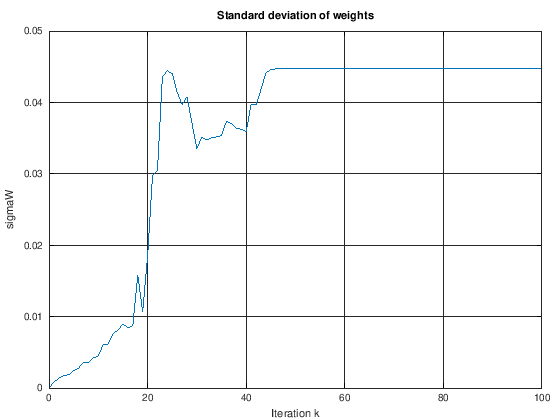

In [9]:
% Plot the standard deviation of the weights versus iteration
plot(0:nIter-1,std(wp)); grid on
xlabel('Iteration k'); ylabel('sigmaW'); 
title('Standard deviation of weights'); xlim([0 nIter-1]);

### Implement the brute-force Bayesian inference solution

In [10]:
% User-specified parameter values
xMin = 0;            % minimum value of xk that is considered
xMax = 450/(180/pi); % maximum value of xk that is considered
nR   = 500;          % number of regions into which xk is divided

In [11]:
% Initialize the estimator by reserving memory
xVals = linspace(xMin,xMax,nR)';  % these are the region edges
w     = mean(diff(xVals));        % this is the region width

fPlus   = zeros(nR,nIter); % f(x{k} | Z{k})
fMinus  = zeros(nR,1);     % f(x{k} | Z{k-1})
xHatMed = zeros(nIter,1);  % median of f(x{k} | Z{k})
xLowBnd = zeros(nIter,1);  % lower confidence of f(x{k} | Z{k})
xHiBnd  = zeros(nIter,1);  % upper confidence of f(x{k} | Z{k})

In [12]:
% Loop to compute f(x{k} | Z{k})
for kk = 1:nIter % when kk = 1, k = 0 (avoid MATLAB index of 0)
  if kk==1 % Initialize
    fMinus = normpdf(xVals,meanX0,sigmaX0);          
  else
    for theR = 1:nR % find f(x{k}=x{i}|x{k-1}) for each x{i}
      % compute prior = f(x{k} | x{k-1})
      prior = normpdf(xVals(theR),xVals+omega,sigmaW);            
      % calc fMinus(theR) = f(x{k} | Z{k-1}) for x{k} = xVals(theR)
      fMinus(theR) = trapz(xVals,prior.*fPlus(:,kk-1));
    end
  end
  % find likelihood = f(z{k} | x{k}) and fPlus = f(x{k} | Z{k})
  likelihood = normpdf(z(kk),atan((r*sin(xVals)+yo)./(r*cos(xVals)+xo)),sigmaV);
  fPlus(:,kk) = likelihood.*fMinus; % not yet normalized
  fPlus(:,kk) = fPlus(:,kk)/trapz(xVals,fPlus(:,kk)); % normalized

  % Find median, 95% confidence interval
  percentiles = cumtrapz(xVals,fPlus(:,kk));
  iMedian = find(percentiles <= 0.5,1,'last');
  iLower = find(percentiles <= 0.025,1,'last');
  if isempty(iLower), iLower = 1; end
  iUpper = find(percentiles >= 0.975,1,'first');
  if isempty(iUpper), iUpper = length(xVals); end
  xHatMed(kk) = xVals(iMedian); % store the median
  xLowBnd(kk) = xVals(iLower);  % store the lower conf. bound
  xHiBnd(kk)  = xVals(iUpper);  % store the upper conf. bound
  
  if mod(kk,10) == 0
    fprintf('Completed iteration %d out of %d\n',kk,nIter);
  end
end % end of main loop, "for kk = 1:nIter"
fprintf('Done!\n');

[~,iMax] = max(fPlus);      % Find index of the mode for each iter
xHatMode = xVals(iMax);     % Store the mode for each iteration
xHatMean = xVals'*fPlus.*w; % Compute the mean for each iteration

Completed iteration 10 out of 101
Completed iteration 20 out of 101
Completed iteration 30 out of 101
Completed iteration 40 out of 101
Completed iteration 50 out of 101
Completed iteration 60 out of 101
Completed iteration 70 out of 101
Completed iteration 80 out of 101
Completed iteration 90 out of 101
Completed iteration 100 out of 101
Done!


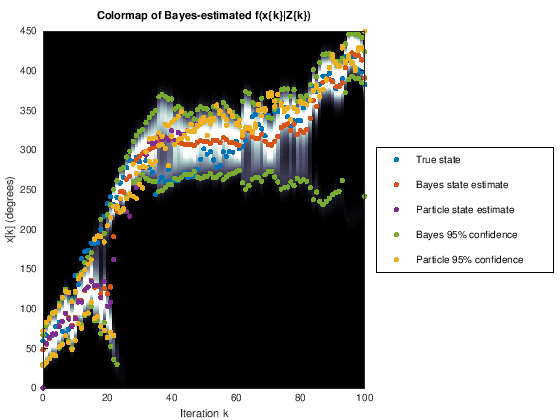

In [13]:
% Plot the colormap of the pdfs versus iteration
colormap('bone'); CL = lines;
imagesc(0:nIter-1,xVals*180/pi,fPlus);
caxis([0,prctile(fPlus(:),95)]); hold on;
k = (0:nIter-1).';
hp1 = plot(k,x*180/pi,'.',k,xHatMean*180/pi,'.');
hp2 = plot(k,xHatPart*180/pi,'.','color',CL(4,:));
hp3 = plot([k;k],[xHiBnd(:);xLowBnd(:)]*180/pi,'.','color',CL(5,:));
hp4 = plot([k;k],[xHiBndPart(:);xLowBndPart(:)]*180/pi,'.','color',CL(3,:));
set([hp1',hp2,hp3,hp4],'markersize',12); 

xlabel('Iteration k'); ylabel('x[k] (degrees)'); 
title('Colormap of Bayes-estimated f(x\{k\}|Z\{k\})');
xlim([0 nIter-1]); ylim([0 450]);
set(gca,'YDir','Normal');
legend({'True state','Bayes state estimate','Particle state estimate',...
        'Bayes 95% confidence','Particle 95% confidence'},'Location','eastoutside');

In [14]:
fprintf('\nParticle-filter (SIS) results:\n');
fprintf('Percent of time estimate is inside confidence interval = %5.3f%%\n',...
         100*sum(xLowBndPart<=x & x<=xHiBndPart)/nIter);
fprintf('Root-mean-squared error of mean = %5.3f\n',...
         rms(x(:)-xHatPart(:)));
         
fprintf('\nBayes results:\n');
fprintf('Percent of time estimate is inside confidence interval = %5.3f%%\n',...
         100*sum(xLowBnd<=x & x<=xHiBnd)/nIter);
fprintf('Root-mean-squared error of mean = %5.3f\n',...
         rms(x(:)-xHatMean(:)));


Particle-filter (SIS) results:
Percent of time estimate is inside confidence interval = 12.871%
Root-mean-squared error of mean = 0.757

Bayes results:
Percent of time estimate is inside confidence interval = 84.158%
Root-mean-squared error of mean = 0.589
